Задание 1. Построение двойственной функции вручную


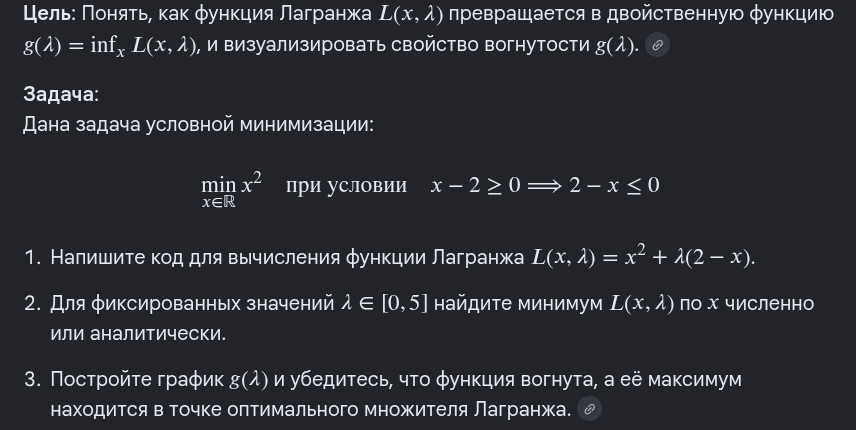

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5365/1387448106.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.axvline(x=4, color='red', linestyle='--', label='$\lambda^* = 4$ (Максимум)')


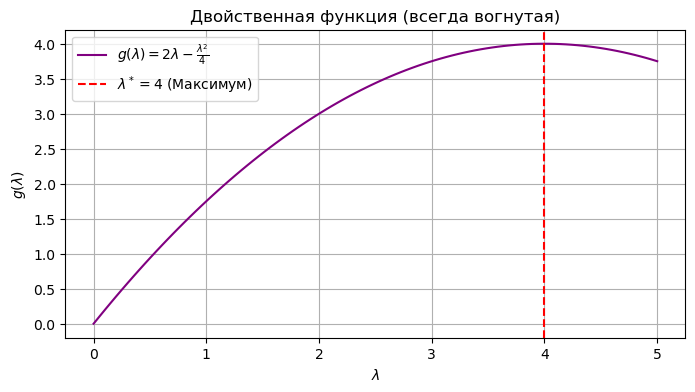

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Функция Лагранжа
def lagrangian(x, lam):
    return x**2 + lam * (2 - x)


# 2. Аналитический поиск инфинума по x для каждого lambda:
# dL/dx = 2x - lam = 0 => x* = lam / 2
# g(lam) = (lam/2)^2 + lam*(2 - lam/2) = 2*lam - (lam^2)/4
def dual_function(lam):
    x_opt = lam / 2
    return lagrangian(x_opt, lam)


lambdas = np.linspace(0, 5, 100)
g_values = dual_function(lambdas)

# 3. Визуализация
plt.figure(figsize=(8, 4))
plt.plot(lambdas, g_values, label=r"$g(\lambda) = 2\lambda - \frac{\lambda^2}{4}$", color="purple")
plt.axvline(x=4, color="red", linestyle="--", label="$\lambda^* = 4$ (Максимум)")
plt.title("Двойственная функция (всегда вогнутая)")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$g(\lambda)$")
plt.legend()
plt.grid(True)
plt.show()

Задание 2. Проверка слабой двойственности (Weak Duality)

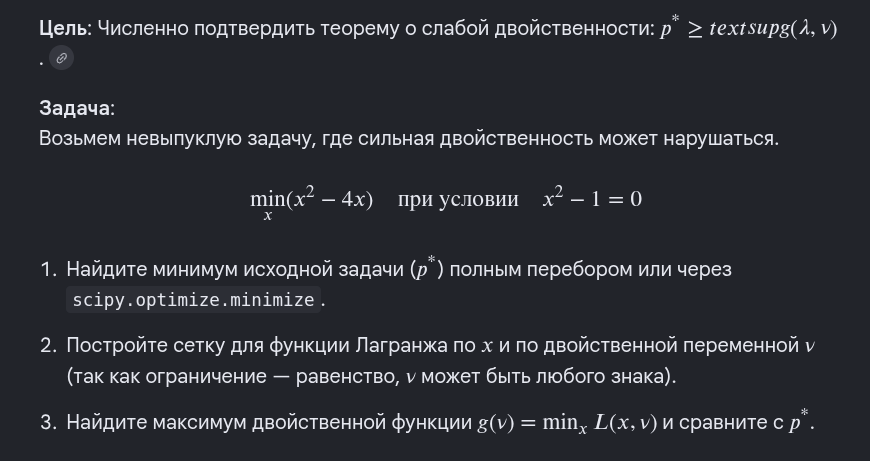

In [ ]:
from scipy.optimize import minimize


# Прямая задача
def primal_obj(x):
    return x[0] ** 2 - 4 * x[0]


cons = {"type": "eq", "fun": lambda x: x[0] ** 2 - 1}

# Решение прямой задачи
res_primal = minimize(primal_obj, x0=[0.0], constraints=cons)
p_star = res_primal.fun
print(f"Оптимальное значение прямой задачи (p*): {p_star:.4f}")


# Вычисление двойственной функции g(nu)
def get_g_value(nu):
    # Внутренний минимум по x для фиксированного nu
    L = lambda x: (x**2 - 4 * x) + nu * (x**2 - 1)
    res = minimize(L, x0=[0.0])
    return res.fun


# Считаем g(nu) на сетке, чтобы найти максимум (d*)
nu_grid = np.linspace(-2, 2, 100)
g_grid = [get_g_value(nu) for nu in nu_grid]
d_star = max(g_grid)

print(f"Максимум двойственной функции (d*): {d_star:.4f}")
print(f"Проверка слабой двойственности (p* >= d*): {p_star >= d_star}")

Оптимальное значение прямой задачи (p*): -3.0000
Максимум двойственной функции (d*): -3.0001
Проверка слабой двойственности (p* >= d*): True


Задание 3. Сильная двойственность и зазор двойственности (Duality Gap)

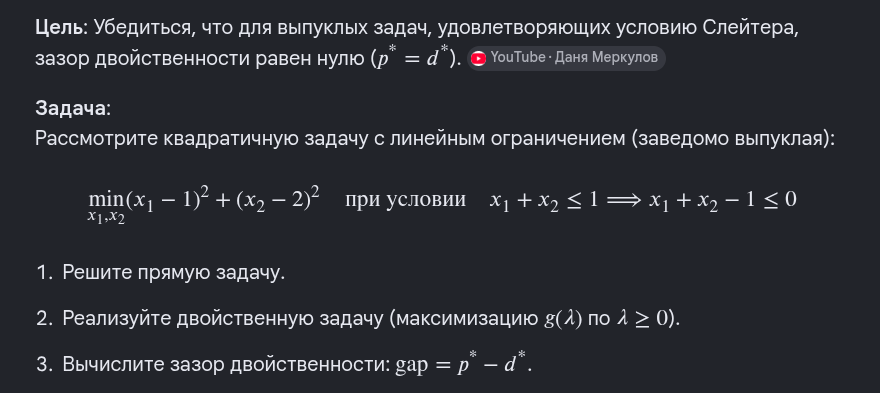

In [ ]:
# Прямая задача
def objective(x):
    return (x[0] - 1) ** 2 + (x[1] - 2) ** 2


constraints = {"type": "ineq", "fun": lambda x: 1 - (x[0] + x[1])}  # 1 - x1 - x2 >= 0
res_p = minimize(objective, x0=[0, 0], constraints=constraints)
p_star = res_p.fun


# Двойственная функция g(lam)
def dual_obj_neg(lam):
    if lam < 0:
        return float("inf")  # Лагранж для неравенств требует lam >= 0
    # Внутренняя минимизация по x
    L = lambda x: (x[0] - 1) ** 2 + (x[1] - 2) ** 2 + lam * (x[0] + x[1] - 1)
    res = minimize(L, x0=[0, 0])
    return -res.fun  # Минимизируем минус g, чтобы максимизировать g


# Максимизируем двойственную функцию
res_d = minimize(dual_obj_neg, x0=[0.5], method="Nelder-Mead")
d_star = -res_d.fun

print(f"p* (Primal): {p_star:.6f}")
print(f"d* (Dual):   {d_star:.6f}")
print(f"Зазор двойственности (Duality Gap): {p_star - d_star:.6f}")

p* (Primal): 2.000000
d* (Dual):   2.000000
Зазор двойственности (Duality Gap): -0.000000


Задание 4. Проверка условий ККТ (Karush-Kuhn-Tucker)

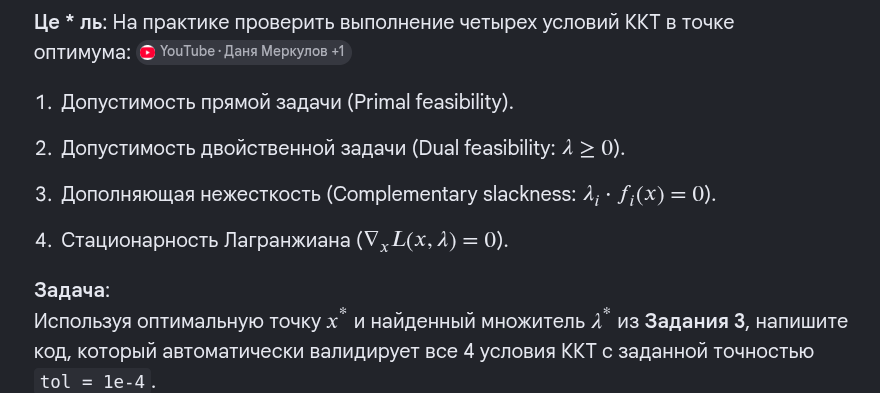

In [ ]:
x_opt = res_p.x
# Из аналитического решения этой задачи известно, что lam* = 2
lam_opt = 2.0

print(f"Оптимальная точка x*: {x_opt}")
print(f"Оптимальный множитель lam*: {lam_opt}\n")

# 1. Primal feasibility
primal_feasible = (x_opt[0] + x_opt[1] - 1) <= 1e-4
print(f"1. Допустимость прямой (x1 + x2 <= 1): {primal_feasible}")

# 2. Dual feasibility
dual_feasible = lam_opt >= 0
print(f"2. Допустимость двойственной (lam >= 0): {dual_feasible}")

# 3. Complementary slackness
slackness = abs(lam_opt * (x_opt[0] + x_opt[1] - 1))
print(f"3. Дополняющая нежесткость (lam * f(x) == 0): {slackness < 1e-4} (Значение: {slackness:.6f})")

# 4. Stationarity: dL/dx1 = 2(x1 - 1) + lam, dL/dx2 = 2(x2 - 2) + lam
grad_L_x1 = 2 * (x_opt[0] - 1) + lam_opt
grad_L_x2 = 2 * (x_opt[1] - 2) + lam_opt
stationarity = abs(grad_L_x1) < 1e-4 and abs(grad_L_x2) < 1e-4
print(f"4. Стационарность (grad L == 0): {stationarity} (Градиент: [{grad_L_x1:.4f}, {grad_L_x2:.4f}])")

Оптимальная точка x*: [8.27853758e-11 1.00000000e+00]
Оптимальный множитель lam*: 2.0

1. Допустимость прямой (x1 + x2 <= 1): True
2. Допустимость двойственной (lam >= 0): True
3. Дополняющая нежесткость (lam * f(x) == 0): True (Значение: 0.000000)
4. Стационарность (grad L == 0): True (Градиент: [0.0000, -0.0000])
